In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("data.csv")

In [29]:
df = df[df['price'] > 0]

In [4]:
df['country'].unique()

array(['USA'], dtype=object)

In [5]:
df.drop(['country'], axis=1 , inplace = True)

In [17]:
df.drop(['date'], axis=1 , inplace = True)

In [21]:
df['statezip'].unique()

array(['WA 98133', 'WA 98119', 'WA 98042', 'WA 98008', 'WA 98052',
       'WA 98115', 'WA 98038', 'WA 98045', 'WA 98155', 'WA 98105',
       'WA 98074', 'WA 98106', 'WA 98007', 'WA 98092', 'WA 98198',
       'WA 98006', 'WA 98102', 'WA 98011', 'WA 98125', 'WA 98003',
       'WA 98136', 'WA 98033', 'WA 98029', 'WA 98117', 'WA 98034',
       'WA 98072', 'WA 98023', 'WA 98107', 'WA 98166', 'WA 98116',
       'WA 98024', 'WA 98055', 'WA 98077', 'WA 98027', 'WA 98059',
       'WA 98075', 'WA 98014', 'WA 98065', 'WA 98199', 'WA 98053',
       'WA 98058', 'WA 98122', 'WA 98103', 'WA 98112', 'WA 98005',
       'WA 98118', 'WA 98177', 'WA 98004', 'WA 98019', 'WA 98144',
       'WA 98168', 'WA 98001', 'WA 98056', 'WA 98146', 'WA 98028',
       'WA 98148', 'WA 98057', 'WA 98040', 'WA 98010', 'WA 98051',
       'WA 98031', 'WA 98109', 'WA 98030', 'WA 98126', 'WA 98032',
       'WA 98178', 'WA 98288', 'WA 98108', 'WA 98070', 'WA 98188',
       'WA 98002', 'WA 98039', 'WA 98022', 'WA 98068', 'WA 980

In [22]:
df.drop(['statezip'], axis=1 , inplace = True)

In [24]:
df.drop(['street'], axis=1 , inplace = True)

In [8]:
from sklearn.preprocessing import LabelEncoder

In [11]:
mean_price = df.groupby('city')['price'].mean()
df['city_mean_encoded'] = df['city'].map(mean_price)

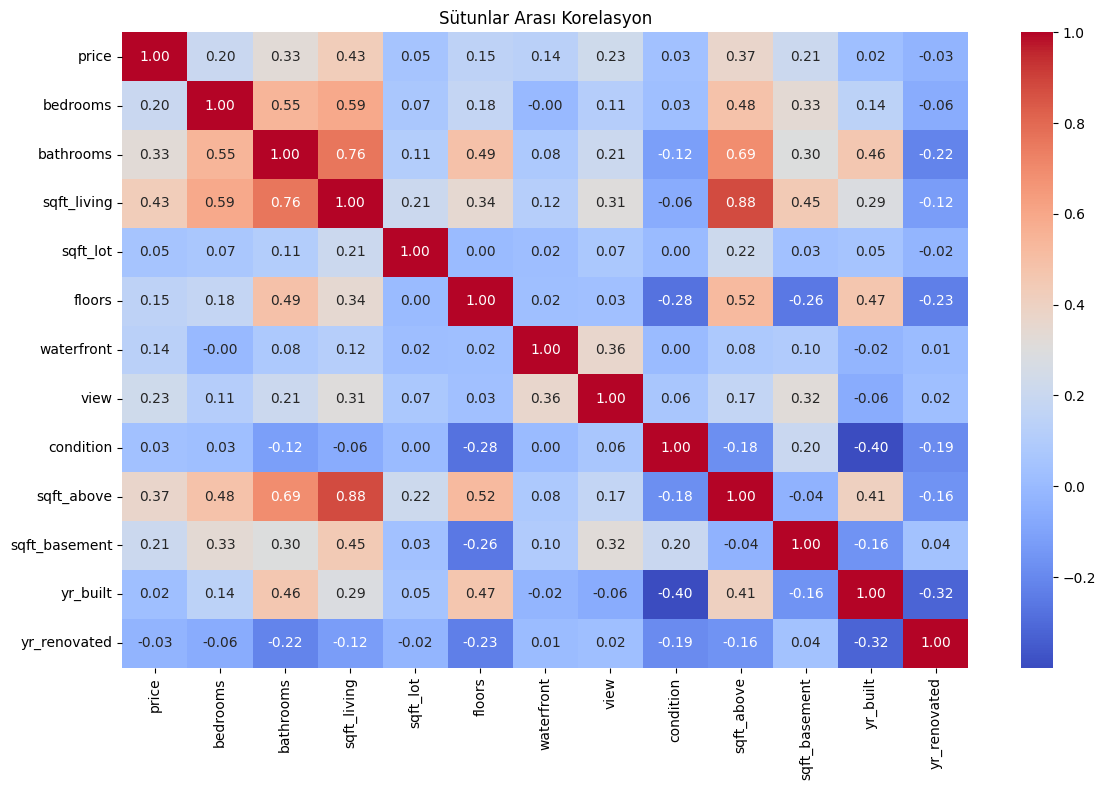

In [14]:
numeric_df = df[['price', 'bedrooms', 'bathrooms', 'sqft_living',
                  'sqft_lot', 'floors', 'waterfront', 'view',
                  'condition', 'sqft_above', 'sqft_basement',
                  'yr_built', 'yr_renovated']]
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Sütunlar Arası Korelasyon')
plt.tight_layout()
plt.show()


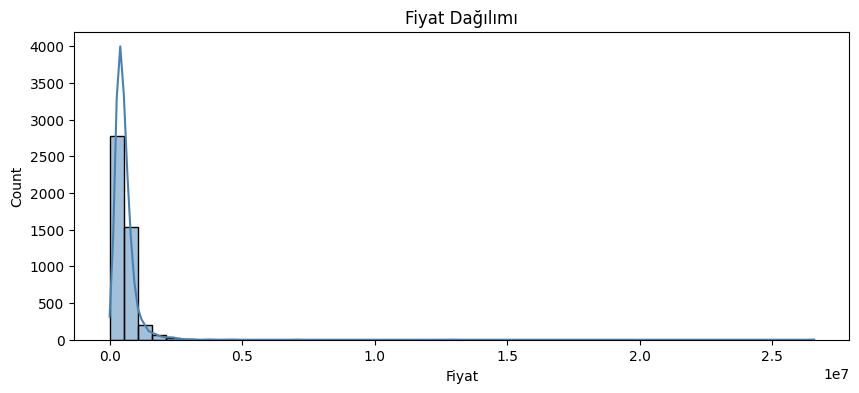

In [15]:
plt.figure(figsize=(10, 4))
sns.histplot(df['price'], bins=50, kde=True, color='steelblue')
plt.title('Fiyat Dağılımı')
plt.xlabel('Fiyat')
plt.show()

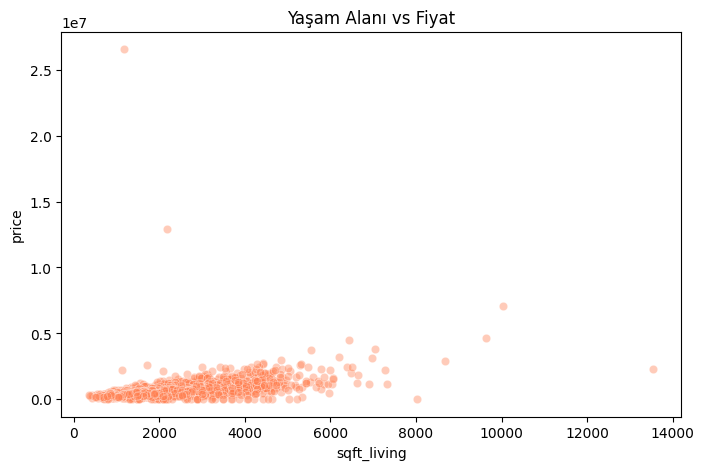

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.4, color='coral')
plt.title('Yaşam Alanı vs Fiyat')
plt.show()

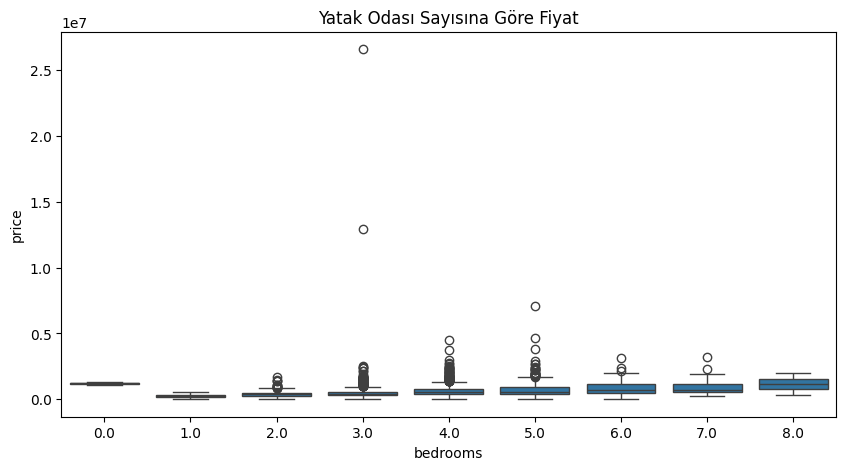

In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['bedrooms'] <= 8], x='bedrooms', y='price')
plt.title('Yatak Odası Sayısına Göre Fiyat')
plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_8292\1404852729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_avg.index, y=city_avg.values, palette='viridis')


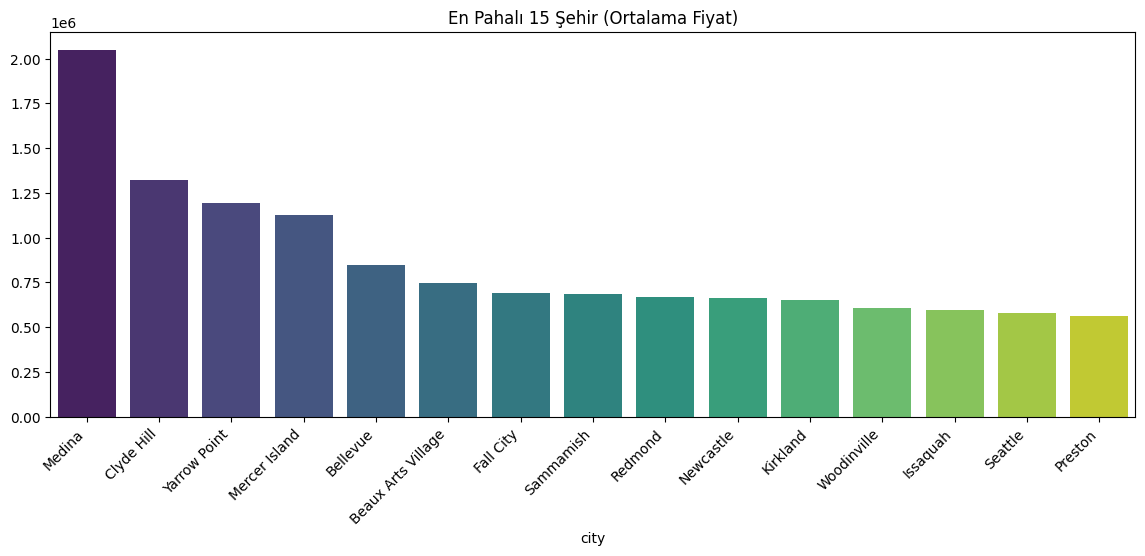

In [26]:
plt.figure(figsize=(14, 5))
city_avg = df.groupby('city')['price'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=city_avg.index, y=city_avg.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('En Pahalı 15 Şehir (Ortalama Fiyat)')
plt.show()

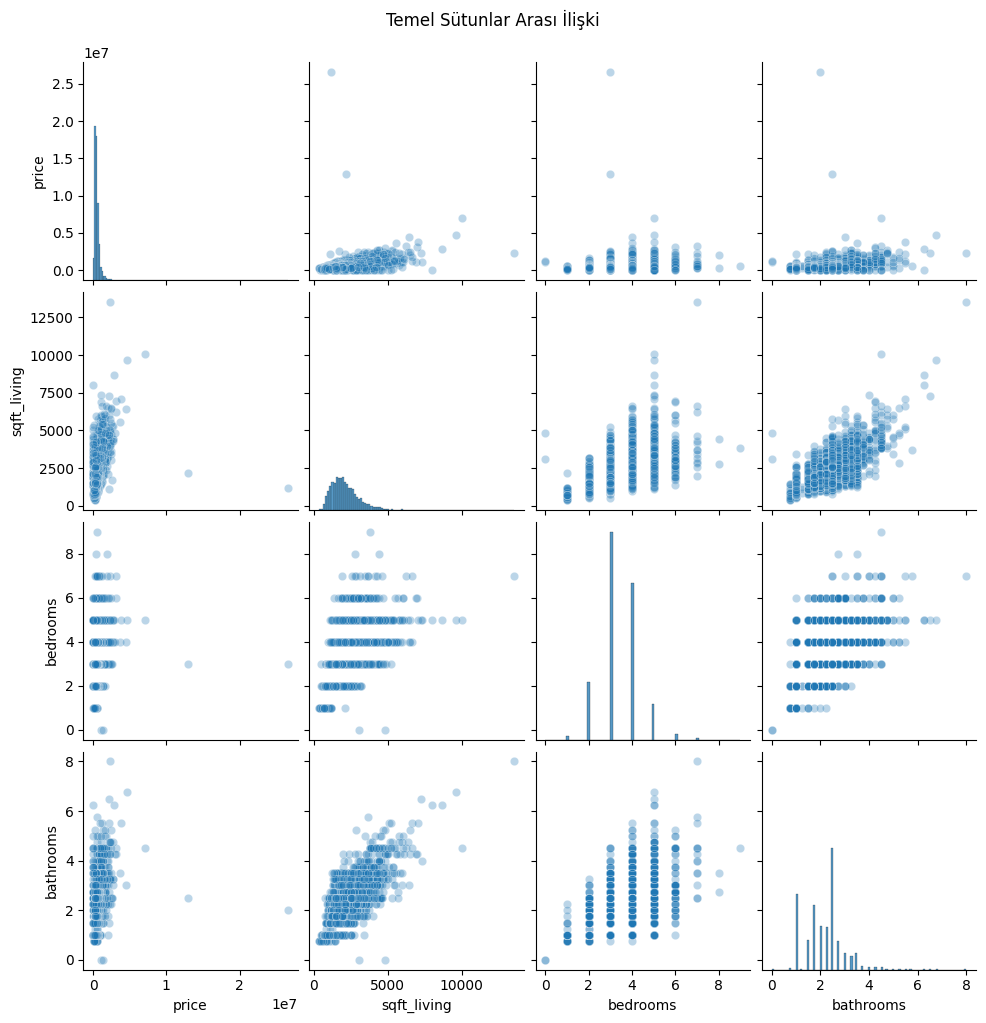

In [27]:
sns.pairplot(df[['price', 'sqft_living', 'bedrooms', 'bathrooms']].dropna(),
             plot_kws={'alpha': 0.3})
plt.suptitle('Temel Sütunlar Arası İlişki', y=1.02)
plt.show()

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [35]:
features = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
    'floors', 'waterfront', 'view', 'condition',
    'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
    'city_mean_encoded'  
]

X = df[features]
y = df['price']

In [36]:
X = X.fillna(X.median())

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [39]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-44061.24, 51248.41,102938.2 ,...,-59302.54, 2274.41,126553.99]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.583e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[117.28, 85.59, 67.76,..., 37.52, 29.07, 0. ]"


In [40]:
y_pred = model.predict(X_test_scaled)

In [43]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MSE  : {mse:,.0f}")
print(f"RMSE : {rmse:,.0f}  ← ortalama hata (dolar)")
print(f"R²   : {r2:.4f}   ← 1'e ne kadar yakınsa o kadar iyi")


MSE  : 47,050,554,511
RMSE : 216,911  ← ortalama hata (dolar)
R²   : 0.6837   ← 1'e ne kadar yakınsa o kadar iyi


In [44]:
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("\nKatsayılar (büyük = fiyata etkisi fazla):")
print(coef_df.to_string(index=False))


Katsayılar (büyük = fiyata etkisi fazla):
          Feature   Coefficient
city_mean_encoded 126553.985671
      sqft_living 102938.196322
       sqft_above 100619.679027
        bathrooms  51248.405779
             view  44978.663234
       waterfront  33626.005092
    sqft_basement  24673.262531
        condition  21908.889531
           floors   7910.799951
     yr_renovated   2274.408744
         sqft_lot -13341.260673
         bedrooms -44061.244914
         yr_built -59302.542919


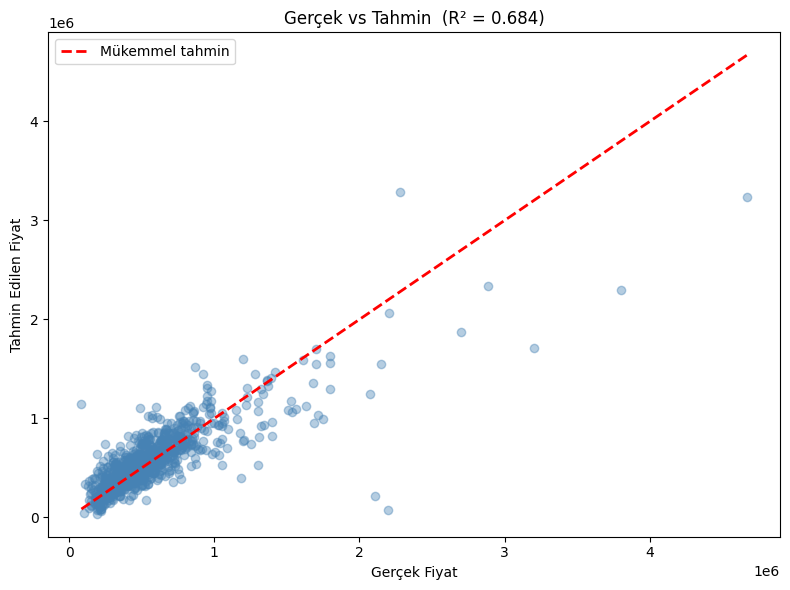

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Mükemmel tahmin')
plt.xlabel('Gerçek Fiyat')
plt.ylabel('Tahmin Edilen Fiyat')
plt.title(f'Gerçek vs Tahmin  (R² = {r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

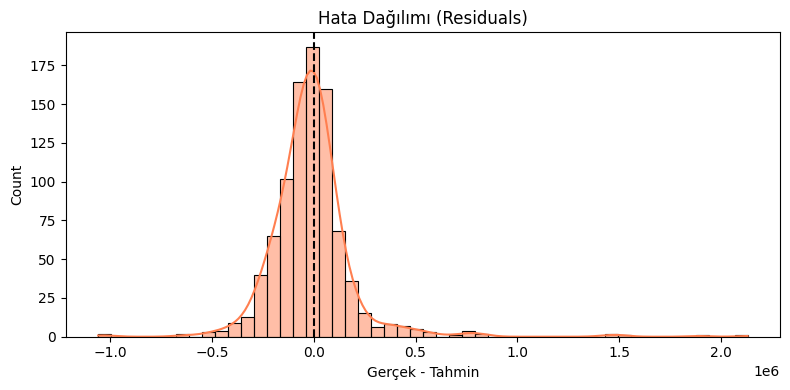

In [46]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=50, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--')
plt.title('Hata Dağılımı (Residuals)')
plt.xlabel('Gerçek - Tahmin')
plt.tight_layout()
plt.show()


C:\Users\MSI\AppData\Local\Temp\ipykernel_8292\3381222497.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')


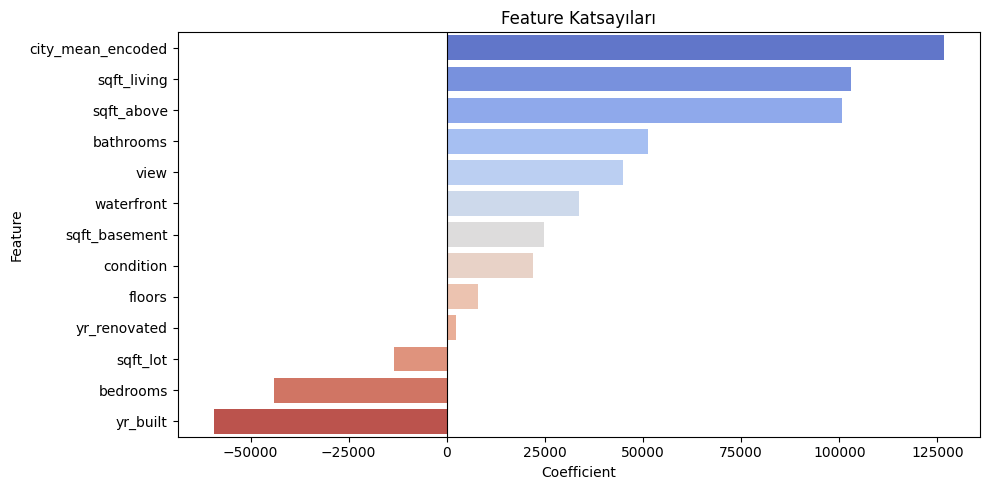

In [47]:
plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Feature Katsayıları')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()